In [1]:
import copy, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=2)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✓ Libraries loaded")

✓ Libraries loaded


In [2]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        f_wb_i = np.dot(X[i], w) + b
        cost  += (f_wb_i - y[i]) ** 2
    return cost / (2 * m)


def compute_gradient(X, y, w, b):
    m, n  = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.0
    for i in range(m):
        err = np.dot(X[i], w) + b - y[i]
        for j in range(n):
            dj_dw[j] += err * X[i, j]
        dj_db += err
    dj_dw /= m
    dj_db /= m
    return dj_dw, dj_db


def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
    J_history = []
    w = copy.deepcopy(w_in)
    b = b_in
    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        if i < 100000:
            J_history.append(cost_function(X, y, w, b))
        if i % math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:5d}: Cost {J_history[-1]:15.4f}")
    return w, b, J_history


def zscore_normalize_features(X):
    mu     = np.mean(X, axis=0)
    sigma  = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

print("✓ Functions loaded")

✓ Functions loaded


Iteration     0: Cost      11088.1997
Iteration  1000: Cost        695.9515
Iteration  2000: Cost        589.3931
Iteration  3000: Cost        527.0076
Iteration  4000: Cost        490.4834
Iteration  5000: Cost        469.1000
Iteration  6000: Cost        456.5808
Iteration  7000: Cost        449.2514
Iteration  8000: Cost        444.9603
Iteration  9000: Cost        442.4481


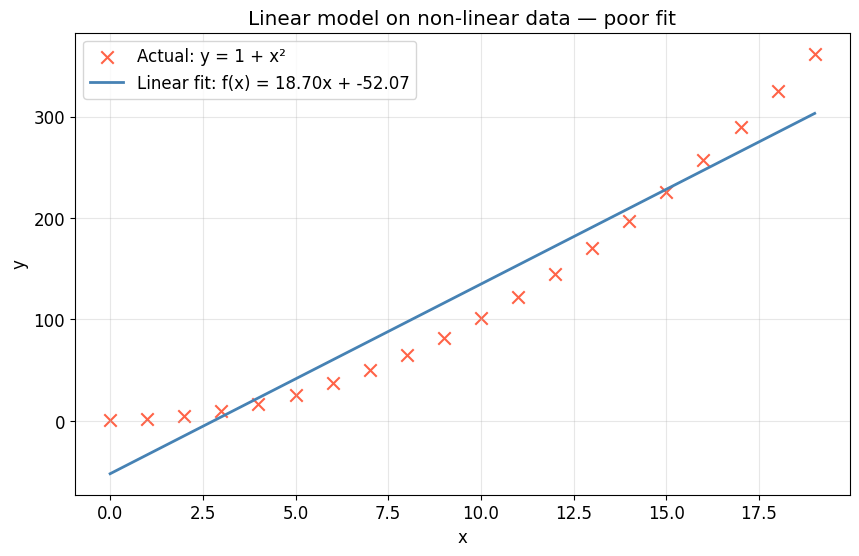


Final cost (linear): 440.9784  ← still high, can't fit the curve


In [3]:
# True relationship: y = 1 + x²
x = np.arange(0, 20, 1)
y = 1 + x ** 2

# Reshape to matrix (m, 1) — one feature
X = x.reshape(-1, 1).astype(float)

m, n = X.shape
initial_w = np.zeros(n)
initial_b = 0.

w_linear, b_linear, J_hist_linear = gradient_descent(
    X, y, initial_w, initial_b,
    compute_cost, compute_gradient,
    alpha=1e-3, num_iters=10000
)

# Plot result
x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
y_line = x_line * w_linear + b_linear

plt.scatter(x, y, color='tomato', marker='x', s=80, label='Actual: y = 1 + x²')
plt.plot(x_line, y_line, color='steelblue', linewidth=2, label=f'Linear fit: f(x) = {w_linear[0]:.2f}x + {b_linear:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear model on non-linear data — poor fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFinal cost (linear): {J_hist_linear[-1]:.4f}  ← still high, can't fit the curve")

Iteration     0: Cost      11494.4265
Iteration  1000: Cost          0.0000
Iteration  2000: Cost          0.0000
Iteration  3000: Cost          0.0000
Iteration  4000: Cost          0.0000
Iteration  5000: Cost          0.0000
Iteration  6000: Cost          0.0000
Iteration  7000: Cost          0.0000
Iteration  8000: Cost          0.0000
Iteration  9000: Cost          0.0000


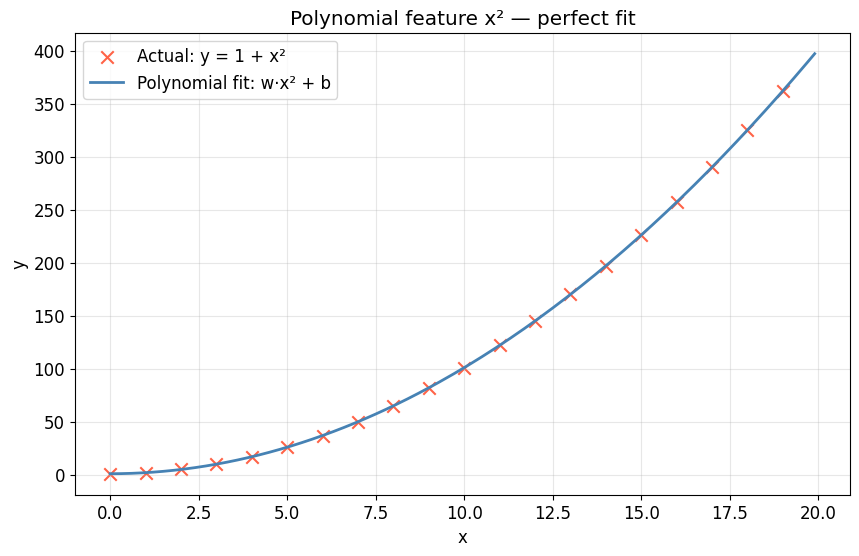


Final cost (polynomial x²): 0.000000  ← near zero!
w = [113.49],  b = 124.5000


In [4]:
# Engineer the feature: replace x with x²
x = np.arange(0, 20, 1)
y = 1 + x ** 2

X_poly = (x ** 2).reshape(-1, 1).astype(float)   # ← only x² as feature

# Normalize — critical because x² has a much larger range than x
X_poly_norm, mu_poly, sigma_poly = zscore_normalize_features(X_poly)

m, n = X_poly_norm.shape
initial_w = np.zeros(n)
initial_b = 0.

w_poly, b_poly, J_hist_poly = gradient_descent(
    X_poly_norm, y, initial_w, initial_b,
    compute_cost, compute_gradient,
    alpha=1e-1, num_iters=10000
)

# Plot
x_plot      = np.arange(0, 20, 0.1)
X_plot_poly = ((x_plot ** 2).reshape(-1, 1) - mu_poly) / sigma_poly
y_plot      = X_plot_poly @ w_poly + b_poly

plt.scatter(x, y, color='tomato', marker='x', s=80, label='Actual: y = 1 + x²')
plt.plot(x_plot, y_plot, color='steelblue', linewidth=2, label='Polynomial fit: w·x² + b')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial feature x² — perfect fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFinal cost (polynomial x²): {J_hist_poly[-1]:.6f}  ← near zero!")
print(f"w = {w_poly},  b = {b_poly:.4f}")

In [5]:
x = np.arange(0, 20, 1)
y = x ** 2   # true relationship: y = x²

# Engineer three features
X_multi = np.c_[x, x**2, x**3].astype(float)
print(f"X_multi shape: {X_multi.shape}  → features: [x, x², x³]")
print(f"Peak to peak range — Raw: {np.ptp(X_multi, axis=0)}")

# Normalize — CRITICAL: x³ goes up to 6859, completely different scale from x
X_multi_norm, mu_multi, sigma_multi = zscore_normalize_features(X_multi)
print(f"Peak to peak range — Normalized: {np.ptp(X_multi_norm, axis=0).round(2)}")

m, n = X_multi_norm.shape
initial_w = np.zeros(n)
initial_b = 0.

w_multi, b_multi, J_hist_multi = gradient_descent(
    X_multi_norm, y, initial_w, initial_b,
    compute_cost, compute_gradient,
    alpha=1e-1, num_iters=10000
)

print(f"\nLearned weights:")
for i, (feat, wi) in enumerate(zip(['x', 'x²', 'x³'], w_multi)):
    print(f"  w[{i}] ({feat:3s}): {wi:.4f}  {'← most important!' if abs(wi) == max(abs(w_multi)) else ''}")
print(f"  b        : {b_multi:.4f}")
print(f"\nFinal cost: {J_hist_multi[-1]:.6f}")

X_multi shape: (20, 3)  → features: [x, x², x³]
Peak to peak range — Raw: [  19.  361. 6859.]
Peak to peak range — Normalized: [3.3  3.18 3.28]
Iteration     0: Cost       9421.4668
Iteration  1000: Cost          4.2152
Iteration  2000: Cost          3.2365
Iteration  3000: Cost          2.4850
Iteration  4000: Cost          1.9080
Iteration  5000: Cost          1.4650
Iteration  6000: Cost          1.1248
Iteration  7000: Cost          0.8637
Iteration  8000: Cost          0.6631
Iteration  9000: Cost          0.5092

Learned weights:
  w[0] (x  ): 7.6745  
  w[1] (x² ): 93.9463  ← most important!
  w[2] (x³ ): 12.2887  
  b        : 123.5000

Final cost: 0.391042


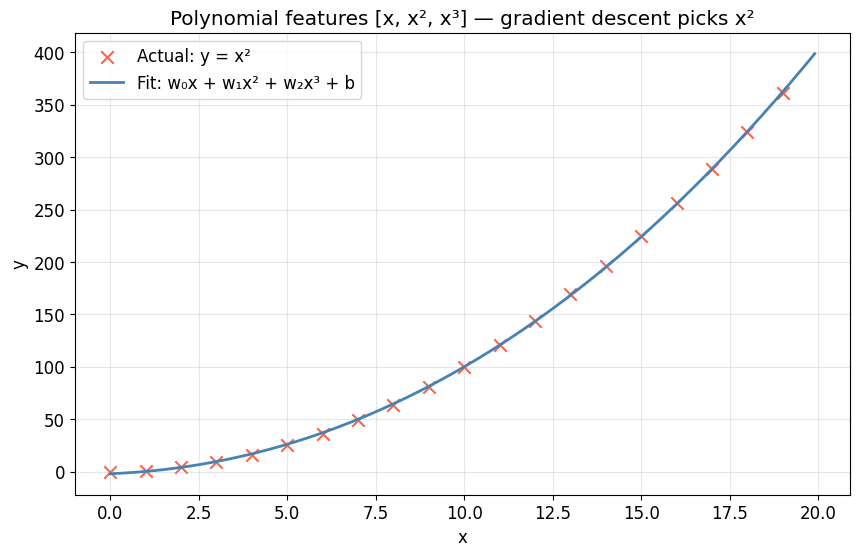

In [6]:
x_plot       = np.arange(0, 20, 0.1)
X_plot_multi = np.c_[x_plot, x_plot**2, x_plot**3].astype(float)
X_plot_norm  = (X_plot_multi - mu_multi) / sigma_multi
y_plot       = X_plot_norm @ w_multi + b_multi

plt.scatter(x, y, color='tomato', marker='x', s=80, label='Actual: y = x²')
plt.plot(x_plot, y_plot, color='steelblue', linewidth=2, label='Fit: w₀x + w₁x² + w₂x³ + b')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial features [x, x², x³] — gradient descent picks x²')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
print("Feature ranges BEFORE normalization:")
X_raw = np.c_[x, x**2, x**3].astype(float)
for i, feat in enumerate(['x', 'x²', 'x³']):
    print(f"  {feat:4s}: {X_raw[:,i].min():.0f}  to  {X_raw[:,i].max():.0f}")

print("\nFeature ranges AFTER z-score normalization:")
for i, feat in enumerate(['x', 'x²', 'x³']):
    print(f"  {feat:4s}: {X_multi_norm[:,i].min():.2f}  to  {X_multi_norm[:,i].max():.2f}")

Feature ranges BEFORE normalization:
  x   : 0  to  19
  x²  : 0  to  361
  x³  : 0  to  6859

Feature ranges AFTER z-score normalization:
  x   : -1.65  to  1.65
  x²  : -1.09  to  2.09
  x³  : -0.86  to  2.42


In [9]:
df = pd.read_csv('../data/multivariate.csv')
df = df.rename(columns={'price_uds': 'price_usd'})

X_base = df[['size_sqm', 'bedrooms', 'age_years']].values.astype(float)
y      = df['price_usd'].values.astype(float)

# Engineer new features
size     = X_base[:, 0]
bedrooms = X_base[:, 1]
age      = X_base[:, 2]

size_sq      = size ** 2                  # captures non-linear size effect
size_x_bed   = size * bedrooms            # interaction: size AND bedrooms together

# Build extended feature matrix
X_eng = np.c_[size, bedrooms, age, size_sq, size_x_bed]
feature_names = ['size', 'bedrooms', 'age', 'size²', 'size×bed']

print(f"X_base shape    : {X_base.shape}  → 3 features")
print(f"X_eng shape     : {X_eng.shape}   → 5 features (2 engineered)")
print(f"\nPeak to peak range — Raw engineered:")
for i, feat in enumerate(feature_names):
    print(f"  {feat:12s}: {np.ptp(X_eng[:,i]):.0f}")

X_base shape    : (100, 3)  → 3 features
X_eng shape     : (100, 5)   → 5 features (2 engineered)

Peak to peak range — Raw engineered:
  size        : 247
  bedrooms    : 4
  age         : 39
  size²       : 86203
  size×bed    : 1394


In [10]:
# --- Baseline: 3 original features ---
X_base_norm, mu_base, sigma_base = zscore_normalize_features(X_base)
m, n_base = X_base_norm.shape

w_base, b_base, J_base = gradient_descent(
    X_base_norm, y, np.zeros(n_base), 0.,
    compute_cost, compute_gradient,
    alpha=0.1, num_iters=1000
)

# --- Engineered: 5 features ---
X_eng_norm, mu_eng, sigma_eng = zscore_normalize_features(X_eng)
m, n_eng = X_eng_norm.shape

print("\n")
w_eng, b_eng, J_eng = gradient_descent(
    X_eng_norm, y, np.zeros(n_eng), 0.,
    compute_cost, compute_gradient,
    alpha=0.1, num_iters=1000
)

print(f"\n=== Final Cost Comparison ===")
print(f"  Baseline (3 features)      : {J_base[-1]:>15,.2f}")
print(f"  Engineered (5 features)    : {J_eng[-1]:>15,.2f}")
lower = 'Engineered' if J_eng[-1] < J_base[-1] else 'Baseline'
print(f"\n  Better model: {lower}")

Iteration     0: Cost 40680609371.6556
Iteration   100: Cost    7775009.5548
Iteration   200: Cost    7774969.2430
Iteration   300: Cost    7774969.2430
Iteration   400: Cost    7774969.2430
Iteration   500: Cost    7774969.2430
Iteration   600: Cost    7774969.2430
Iteration   700: Cost    7774969.2430
Iteration   800: Cost    7774969.2430
Iteration   900: Cost    7774969.2430


Iteration     0: Cost 39671162662.6298
Iteration   100: Cost   41495787.4340
Iteration   200: Cost   31215049.6783
Iteration   300: Cost   24184437.4209
Iteration   400: Cost   19302896.8896
Iteration   500: Cost   15884700.3547
Iteration   600: Cost   13480062.8959
Iteration   700: Cost   11784192.3200
Iteration   800: Cost   10586560.0356
Iteration   900: Cost    9740170.9415

=== Final Cost Comparison ===
  Baseline (3 features)      :    7,774,969.24
  Engineered (5 features)    :    9,146,794.07

  Better model: Baseline


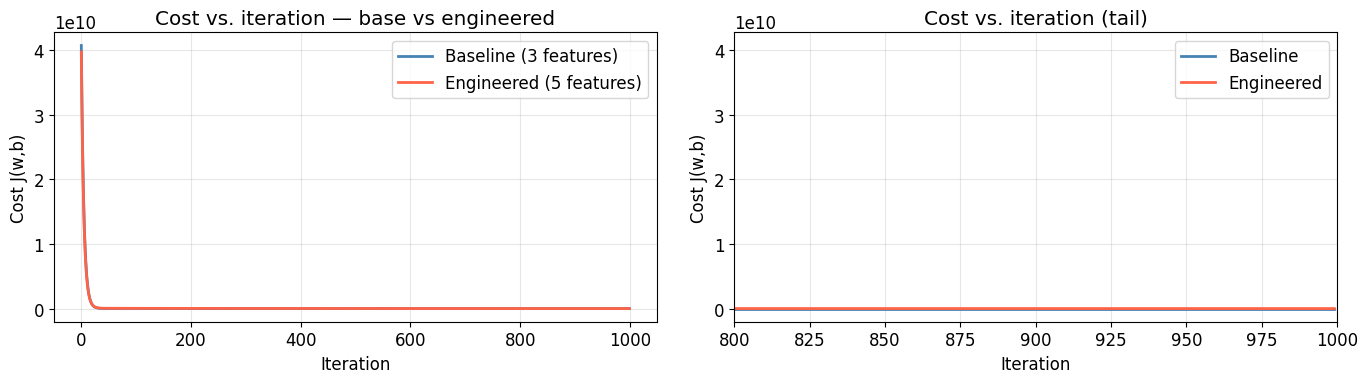

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(J_base, color='steelblue', linewidth=2, label='Baseline (3 features)')
ax1.plot(J_eng,  color='tomato',    linewidth=2, label='Engineered (5 features)')
ax1.set_title("Cost vs. iteration — base vs engineered")
ax1.set_ylabel("Cost J(w,b)")
ax1.set_xlabel("Iteration")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(J_base, color='steelblue', linewidth=2, label='Baseline')
ax2.plot(J_eng,  color='tomato',    linewidth=2, label='Engineered')
ax2.set_title("Cost vs. iteration (tail)")
ax2.set_ylabel("Cost J(w,b)")
ax2.set_xlabel("Iteration")
ax2.set_xlim([800, 1000])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
print("Learned weights — engineered model:")
print("-" * 40)
for feat, wi in zip(feature_names, w_eng):
    bar = '█' * int(abs(wi) / max(abs(w_eng)) * 20)
    print(f"  {feat:12s}: {wi:>10.2f}  {bar}")
print(f"  {'b':12s}: {b_eng:>10.2f}")

Learned weights — engineered model:
----------------------------------------
  size        :   86790.50  ████████████████████
  bedrooms    :   10312.65  ██
  age         :   -6713.97  █
  size²       :    7153.94  █
  size×bed    :    1082.49  
  b           :  302309.19


In [13]:
print("Predictions — Baseline vs Engineered (first 10 examples):")
print("-" * 75)
print(f"  {'Actual':>12}  {'Baseline':>12}  {'Diff':>10}  {'Engineered':>12}  {'Diff':>10}")
print("-" * 75)
for i in range(10):
    pred_base = np.dot(X_base_norm[i], w_base) + b_base
    pred_eng  = np.dot(X_eng_norm[i],  w_eng)  + b_eng
    diff_base = abs(pred_base - y[i])
    diff_eng  = abs(pred_eng  - y[i])
    print(f"  ${y[i]:>10,.0f}  ${pred_base:>10,.0f}  ${diff_base:>8,.0f}  "
          f"${pred_eng:>10,.0f}  ${diff_eng:>8,.0f}")

Predictions — Baseline vs Engineered (first 10 examples):
---------------------------------------------------------------------------
        Actual      Baseline        Diff    Engineered        Diff
---------------------------------------------------------------------------
  $   328,317  $   324,792  $   3,525  $   323,472  $   4,845
  $   399,261  $   395,202  $   4,059  $   395,333  $   3,928
  $   332,917  $   340,044  $   7,127  $   339,234  $   6,317
  $   462,306  $   459,430  $   2,876  $   461,994  $     312
  $   227,808  $   226,744  $   1,064  $   226,660  $   1,148
  $   362,474  $   365,990  $   3,516  $   365,481  $   3,007
  $   402,767  $   405,367  $   2,600  $   405,741  $   2,974
  $   348,825  $   354,411  $   5,586  $   353,491  $   4,666
  $   285,668  $   284,172  $   1,496  $   282,667  $   3,001
  $   290,245  $   290,678  $     433  $   289,034  $   1,211
